In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 239.59it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.49
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 2 # adjustable encoder width for extra compression


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        # z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [18]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    d: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, d: int, slope: np.float64, encoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=d),
            nn.BatchNorm1d(d),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        x_output = self.layers(x)
        return x_output
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(self, d: int, slope: np.float64, latent_dim: int, decoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        self.layers = nn.Sequential(
            nn.Linear(in_features=d, out_features=decoder_features),
            nn.BatchNorm1d(decoder_features),
            nn.LeakyReLU(slope)
        )
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        dec_out = self.layers(x)
        return dec_out
    

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(d=d, slope=slope)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(d=d, latent_dim=latent_dim, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        encoder_output = self.encoder(x)
        b, c, w, h = encoder_output.shape
        encoder_flatten = encoder_output.view(b * c * h, w)
        
        z = self.fc_encoder_input(encoder_flatten)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z)
        
        z_q = self.fc_decoder_input(z_q)
        decoder_input = z_q.view(b, c, h, w)
        
        output = self.decoder(decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [20]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 199/199 [00:00<00:00, 261.53it/s, Loss (BCE + VQ)=0.155]


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.4462,  Average loss: BCE = 0.0705 MSE = 0.008827454717034222 avg_perplexity = 6.677455367754452
Average validation set BCE loss: 0.05928459987044334
Before compression (Training)
Shape: (13, 8, 8)


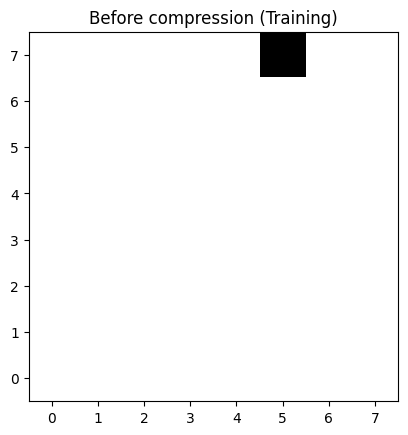

After compression (Training)
Shape: (1, 8, 8)


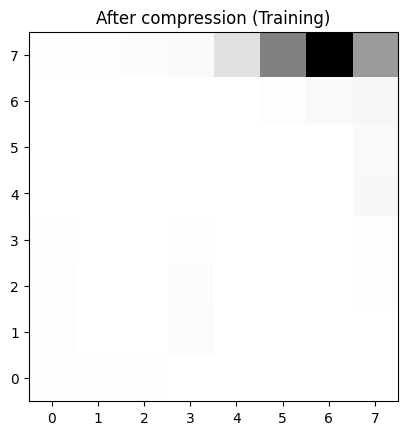

Epoch 2/200: 100%|██████████| 199/199 [00:00<00:00, 336.81it/s, Loss (BCE + VQ)=0.096] 


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.1120,  Average loss: BCE = 0.0554 MSE = 0.006072672788315831 avg_perplexity = 5.974756744039718
Average validation set BCE loss: 0.05437472015619278


Epoch 3/200: 100%|██████████| 199/199 [00:00<00:00, 338.25it/s, Loss (BCE + VQ)=0.0977]


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0819,  Average loss: BCE = 0.0526 MSE = 0.005672278141265913 avg_perplexity = 7.019947490500446
Average validation set BCE loss: 0.053237106651067734


Epoch 4/200: 100%|██████████| 199/199 [00:00<00:00, 345.25it/s, Loss (BCE + VQ)=0.0754]


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0509,  Average loss: BCE = 0.0413 MSE = 0.003821598775404033 avg_perplexity = 12.531974811649802
Average validation set BCE loss: 0.0433311328291893


Epoch 15/200: 100%|██████████| 199/199 [00:00<00:00, 338.30it/s, Loss (BCE + VQ)=0.0331]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0495,  Average loss: BCE = 0.0405 MSE = 0.0037112470819198307 avg_perplexity = 13.419875571476155
Average validation set BCE loss: 0.04340536370873451


Epoch 16/200: 100%|██████████| 199/199 [00:00<00:00, 331.97it/s, Loss (BCE + VQ)=0.0485]


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0491,  Average loss: BCE = 0.0402 MSE = 0.0036372184682047773 avg_perplexity = 13.634671412520673
Average validation set BCE loss: 0.04209337458014488
Before compression (Training)
Shape: (13, 8, 8)


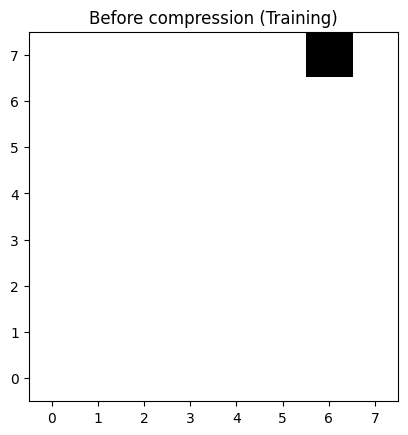

After compression (Training)
Shape: (1, 8, 8)


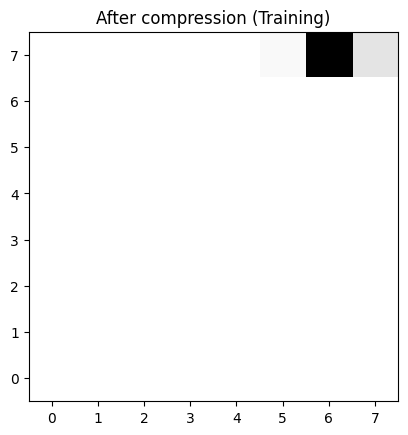

Epoch 17/200: 100%|██████████| 199/199 [00:00<00:00, 341.56it/s, Loss (BCE + VQ)=0.0483]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0484,  Average loss: BCE = 0.0398 MSE = 0.0035922581741782886 avg_perplexity = 13.957640810827513
Average validation set BCE loss: 0.04340565651655197


Epoch 18/200: 100%|██████████| 199/199 [00:00<00:00, 347.84it/s, Loss (BCE + VQ)=0.0394]


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0479,  Average loss: BCE = 0.0395 MSE = 0.0035182933168644882 avg_perplexity = 14.319871720357156
Average validation set BCE loss: 0.04212553650140762


Epoch 19/200: 100%|██████████| 199/199 [00:00<00:00, 350.77it/s, Loss (BCE + VQ)=0.0382]


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0444,  Average loss: BCE = 0.0373 MSE = 0.003155581501017713 avg_perplexity = 15.722446005548065
Average validation set BCE loss: 0.03956208899617195


Epoch 30/200: 100%|██████████| 199/199 [00:00<00:00, 324.01it/s, Loss (BCE + VQ)=0.0328]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0437,  Average loss: BCE = 0.0370 MSE = 0.0030836962092078138 avg_perplexity = 15.852658818115541
Average validation set BCE loss: 0.04082616865634918


Epoch 31/200: 100%|██████████| 199/199 [00:00<00:00, 353.06it/s, Loss (BCE + VQ)=0.0357]


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0435,  Average loss: BCE = 0.0368 MSE = 0.00305720682702865 avg_perplexity = 16.1013953146623
Average validation set BCE loss: 0.03999975547194481
Before compression (Training)
Shape: (13, 8, 8)


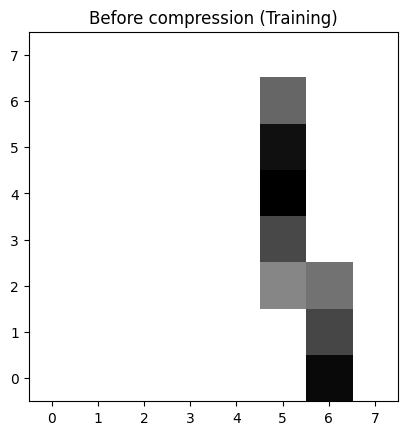

After compression (Training)
Shape: (1, 8, 8)


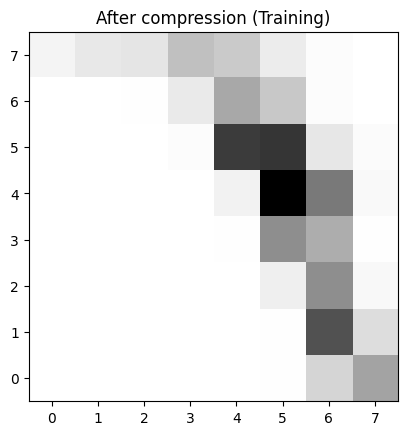

Epoch 32/200: 100%|██████████| 199/199 [00:00<00:00, 323.58it/s, Loss (BCE + VQ)=0.0443]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0429,  Average loss: BCE = 0.0365 MSE = 0.003011623083323652 avg_perplexity = 16.628168245056766
Average validation set BCE loss: 0.0398479700088501


Epoch 33/200: 100%|██████████| 199/199 [00:00<00:00, 335.54it/s, Loss (BCE + VQ)=0.0401]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0427,  Average loss: BCE = 0.0365 MSE = 0.0029930029814388957 avg_perplexity = 17.20429036126065
Average validation set BCE loss: 0.04012523889541626


Epoch 34/200: 100%|██████████| 199/199 [00:00<00:00, 347.40it/s, Loss (BCE + VQ)=0.0361]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0400,  Average loss: BCE = 0.0348 MSE = 0.0026602811992037386 avg_perplexity = 19.48106309516945
Average validation set BCE loss: 0.03810684680938721


Epoch 45/200: 100%|██████████| 199/199 [00:00<00:00, 347.12it/s, Loss (BCE + VQ)=0.0438]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0347 MSE = 0.002624829130097475 avg_perplexity = 19.772648403992005
Average validation set BCE loss: 0.038262522965669635


Epoch 46/200: 100%|██████████| 199/199 [00:00<00:00, 343.10it/s, Loss (BCE + VQ)=0.0287]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0393,  Average loss: BCE = 0.0344 MSE = 0.0025666435576750706 avg_perplexity = 19.902105911293223
Average validation set BCE loss: 0.03803769275546074
Before compression (Training)
Shape: (13, 8, 8)


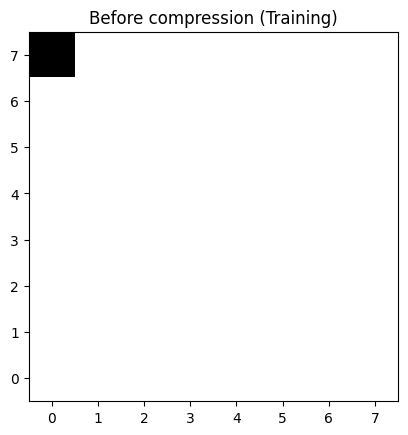

After compression (Training)
Shape: (1, 8, 8)


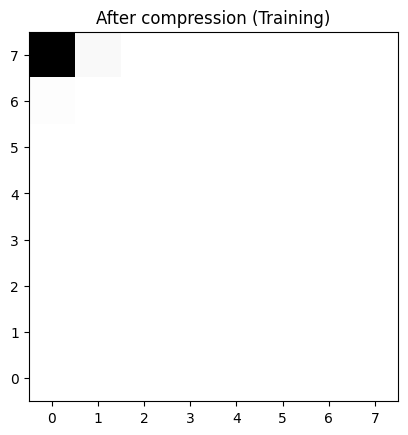

Epoch 47/200: 100%|██████████| 199/199 [00:00<00:00, 335.01it/s, Loss (BCE + VQ)=0.0381]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0346 MSE = 0.00261351019062158 avg_perplexity = 19.912753359157236
Average validation set BCE loss: 0.03843599408864975


Epoch 48/200: 100%|██████████| 199/199 [00:00<00:00, 348.67it/s, Loss (BCE + VQ)=0.0282]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0389,  Average loss: BCE = 0.0342 MSE = 0.0025387909959524346 avg_perplexity = 20.532132584845
Average validation set BCE loss: 0.03797597736120224


Epoch 49/200: 100%|██████████| 199/199 [00:00<00:00, 345.21it/s, Loss (BCE + VQ)=0.0353]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0368,  Average loss: BCE = 0.0330 MSE = 0.0022655620313385247 avg_perplexity = 24.05149410957068
Average validation set BCE loss: 0.037124627828598024


Epoch 60/200: 100%|██████████| 199/199 [00:00<00:00, 342.61it/s, Loss (BCE + VQ)=0.0398]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0367,  Average loss: BCE = 0.0330 MSE = 0.0022362923020281685 avg_perplexity = 24.227455254176153
Average validation set BCE loss: 0.03731842860579491


Epoch 61/200: 100%|██████████| 199/199 [00:00<00:00, 327.50it/s, Loss (BCE + VQ)=0.0347]


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0365,  Average loss: BCE = 0.0328 MSE = 0.0022085324361517875 avg_perplexity = 24.2613336860235
Average validation set BCE loss: 0.03737012892961502
Before compression (Training)
Shape: (13, 8, 8)


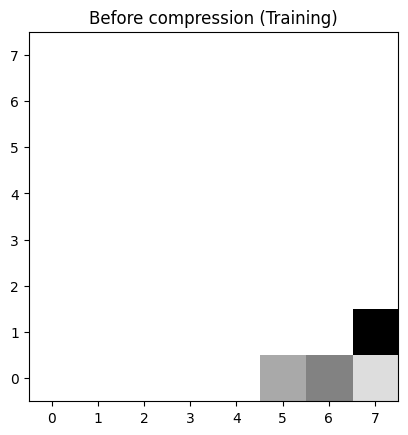

After compression (Training)
Shape: (1, 8, 8)


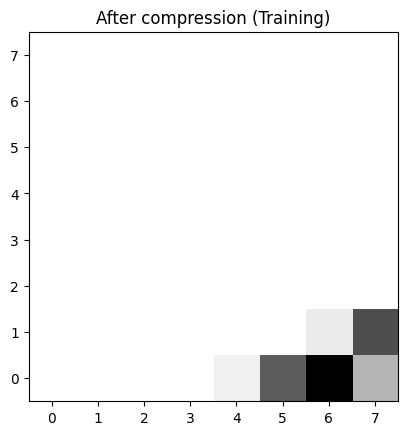

Epoch 62/200: 100%|██████████| 199/199 [00:00<00:00, 335.30it/s, Loss (BCE + VQ)=0.034] 


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0364,  Average loss: BCE = 0.0328 MSE = 0.002198817172724211 avg_perplexity = 24.38105123126926
Average validation set BCE loss: 0.037290295213460924


Epoch 63/200: 100%|██████████| 199/199 [00:00<00:00, 338.11it/s, Loss (BCE + VQ)=0.0408]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0362,  Average loss: BCE = 0.0326 MSE = 0.002175719721766947 avg_perplexity = 24.50126097789362
Average validation set BCE loss: 0.03777308762073517


Epoch 64/200: 100%|██████████| 199/199 [00:00<00:00, 344.82it/s, Loss (BCE + VQ)=0.0333]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0351,  Average loss: BCE = 0.0320 MSE = 0.0020027807662169913 avg_perplexity = 26.710903618203936
Average validation set BCE loss: 0.037814047932624814


Epoch 75/200: 100%|██████████| 199/199 [00:00<00:00, 331.69it/s, Loss (BCE + VQ)=0.0443]


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0350,  Average loss: BCE = 0.0319 MSE = 0.0019913799475747436 avg_perplexity = 26.851202126124395
Average validation set BCE loss: 0.03729039952158928


Epoch 76/200: 100%|██████████| 199/199 [00:00<00:00, 353.36it/s, Loss (BCE + VQ)=0.0438]


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0353,  Average loss: BCE = 0.0321 MSE = 0.002023226541733772 avg_perplexity = 26.746189232447637
Average validation set BCE loss: 0.037437836080789565
Before compression (Training)
Shape: (13, 8, 8)


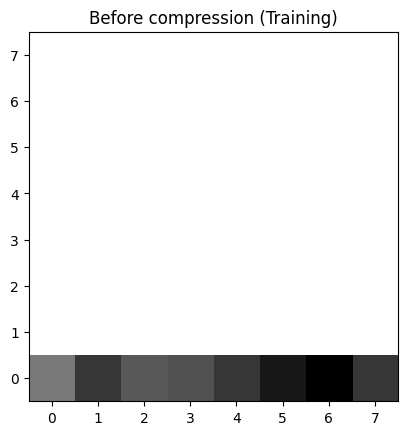

After compression (Training)
Shape: (1, 8, 8)


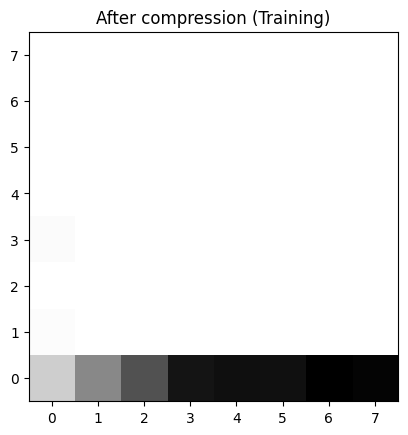

Epoch 77/200: 100%|██████████| 199/199 [00:00<00:00, 342.24it/s, Loss (BCE + VQ)=0.0554]


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0350,  Average loss: BCE = 0.0319 MSE = 0.001978111938320699 avg_perplexity = 27.00127246990875
Average validation set BCE loss: 0.03704889863729477


Epoch 78/200: 100%|██████████| 199/199 [00:00<00:00, 352.00it/s, Loss (BCE + VQ)=0.0388]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0348,  Average loss: BCE = 0.0317 MSE = 0.0019312970669022832 avg_perplexity = 26.980060232344584
Average validation set BCE loss: 0.038470787554979326


Epoch 79/200: 100%|██████████| 199/199 [00:00<00:00, 331.51it/s, Loss (BCE + VQ)=0.0317]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0340,  Average loss: BCE = 0.0311 MSE = 0.0017792226286867082 avg_perplexity = 28.35330327671377
Average validation set BCE loss: 0.03798508867621422


Epoch 90/200: 100%|██████████| 199/199 [00:00<00:00, 326.94it/s, Loss (BCE + VQ)=0.0266]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0340,  Average loss: BCE = 0.0311 MSE = 0.0017941529826312583 avg_perplexity = 28.167268321741766
Average validation set BCE loss: 0.037297286093235016


Epoch 91/200: 100%|██████████| 199/199 [00:00<00:00, 322.10it/s, Loss (BCE + VQ)=0.0262]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0339,  Average loss: BCE = 0.0310 MSE = 0.0017705455623641985 avg_perplexity = 28.363092192453355
Average validation set BCE loss: 0.03686734959483147
Before compression (Training)
Shape: (13, 8, 8)


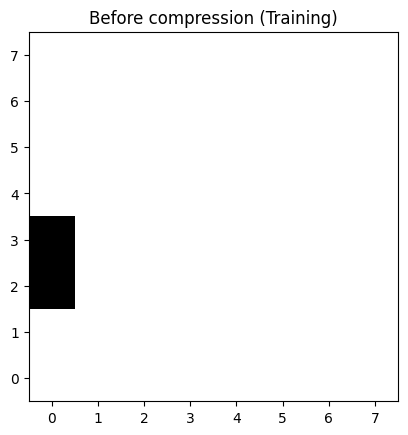

After compression (Training)
Shape: (1, 8, 8)


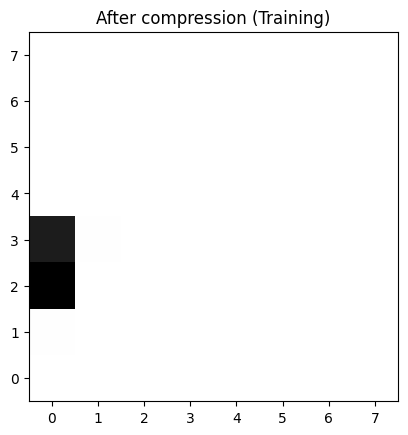

Epoch 92/200: 100%|██████████| 199/199 [00:00<00:00, 334.42it/s, Loss (BCE + VQ)=0.0316]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0338,  Average loss: BCE = 0.0309 MSE = 0.0017326018707499132 avg_perplexity = 28.323484756239694
Average validation set BCE loss: 0.037165024876594545


Epoch 93/200: 100%|██████████| 199/199 [00:00<00:00, 315.22it/s, Loss (BCE + VQ)=0.0374]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0337,  Average loss: BCE = 0.0309 MSE = 0.0017244479269135611 avg_perplexity = 28.40733790757069
Average validation set BCE loss: 0.037035556882619856


Epoch 94/200: 100%|██████████| 199/199 [00:00<00:00, 314.69it/s, Loss (BCE + VQ)=0.0438]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0334,  Average loss: BCE = 0.0307 MSE = 0.0016622706977463323 avg_perplexity = 28.798620712817016
Average validation set BCE loss: 0.036712387949228285


Epoch 105/200: 100%|██████████| 199/199 [00:00<00:00, 345.45it/s, Loss (BCE + VQ)=0.0323]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0331,  Average loss: BCE = 0.0305 MSE = 0.0016001471298999486 avg_perplexity = 28.829341773411738
Average validation set BCE loss: 0.03616826608777046


Epoch 106/200: 100%|██████████| 199/199 [00:00<00:00, 323.34it/s, Loss (BCE + VQ)=0.0239]


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0331,  Average loss: BCE = 0.0305 MSE = 0.0016021515504836138 avg_perplexity = 28.797215533615955
Average validation set BCE loss: 0.03792092278599739
Before compression (Training)
Shape: (13, 8, 8)


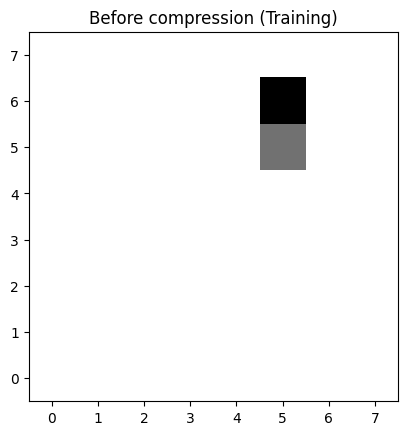

After compression (Training)
Shape: (1, 8, 8)


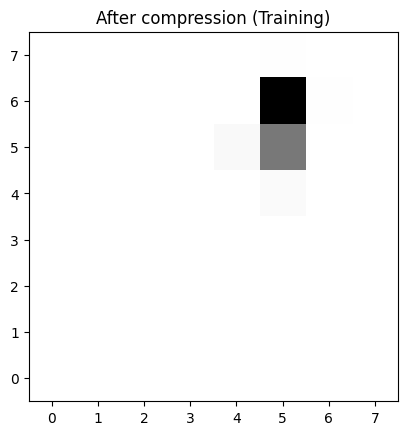

Epoch 107/200: 100%|██████████| 199/199 [00:00<00:00, 341.30it/s, Loss (BCE + VQ)=0.0322]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0330,  Average loss: BCE = 0.0304 MSE = 0.0015629103238198288 avg_perplexity = 28.868278953897295
Average validation set BCE loss: 0.03701929822564125


Epoch 108/200: 100%|██████████| 199/199 [00:00<00:00, 349.61it/s, Loss (BCE + VQ)=0.0267]


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0330,  Average loss: BCE = 0.0304 MSE = 0.001569966049092686 avg_perplexity = 29.107183245558236
Average validation set BCE loss: 0.03714209049940109


Epoch 109/200: 100%|██████████| 199/199 [00:00<00:00, 348.90it/s, Loss (BCE + VQ)=0.038] 


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0327,  Average loss: BCE = 0.0302 MSE = 0.001502718422538484 avg_perplexity = 29.301622237392408
Average validation set BCE loss: 0.03690360821783543


Epoch 120/200: 100%|██████████| 199/199 [00:00<00:00, 325.57it/s, Loss (BCE + VQ)=0.0275]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0324,  Average loss: BCE = 0.0300 MSE = 0.0014674973541908152 avg_perplexity = 29.158060332638534
Average validation set BCE loss: 0.03674073964357376


Epoch 121/200: 100%|██████████| 199/199 [00:00<00:00, 337.86it/s, Loss (BCE + VQ)=0.036] 


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0324,  Average loss: BCE = 0.0300 MSE = 0.0014494606776364223 avg_perplexity = 29.19733801798605
Average validation set BCE loss: 0.03812868595123291
Before compression (Training)
Shape: (13, 8, 8)


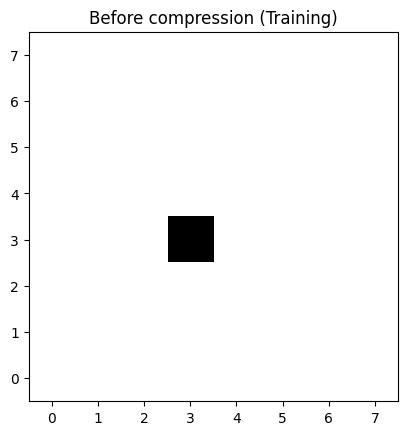

After compression (Training)
Shape: (1, 8, 8)


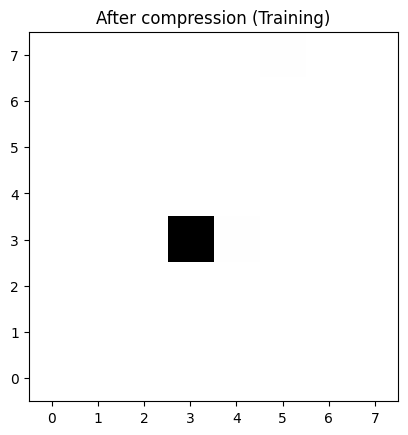

Epoch 122/200: 100%|██████████| 199/199 [00:00<00:00, 342.07it/s, Loss (BCE + VQ)=0.0327]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0325,  Average loss: BCE = 0.0301 MSE = 0.0014858326518407382 avg_perplexity = 29.234974415458026
Average validation set BCE loss: 0.037584435939788816


Epoch 123/200: 100%|██████████| 199/199 [00:00<00:00, 341.45it/s, Loss (BCE + VQ)=0.0309]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0325,  Average loss: BCE = 0.0300 MSE = 0.0014629157256550302 avg_perplexity = 29.310761293574195
Average validation set BCE loss: 0.037371132522821426


Epoch 124/200: 100%|██████████| 199/199 [00:00<00:00, 318.13it/s, Loss (BCE + VQ)=0.037] 


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0320,  Average loss: BCE = 0.0297 MSE = 0.001378817445757663 avg_perplexity = 29.740873681839986
Average validation set BCE loss: 0.037773369997739795


Epoch 135/200: 100%|██████████| 199/199 [00:00<00:00, 333.42it/s, Loss (BCE + VQ)=0.0271]


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0319,  Average loss: BCE = 0.0296 MSE = 0.001344197726312407 avg_perplexity = 29.674595492569047
Average validation set BCE loss: 0.03795948103070259


Epoch 136/200: 100%|██████████| 199/199 [00:00<00:00, 344.07it/s, Loss (BCE + VQ)=0.0394]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0319,  Average loss: BCE = 0.0297 MSE = 0.0013632303415025448 avg_perplexity = 29.779257913330692
Average validation set BCE loss: 0.037702757865190506
Before compression (Training)
Shape: (13, 8, 8)


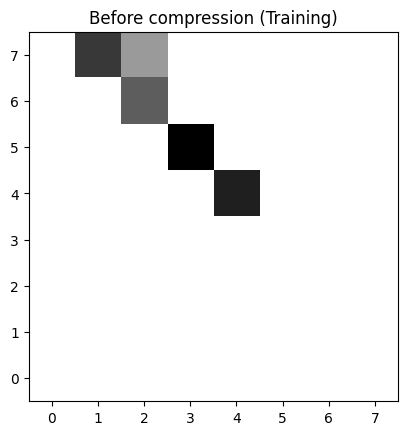

After compression (Training)
Shape: (1, 8, 8)


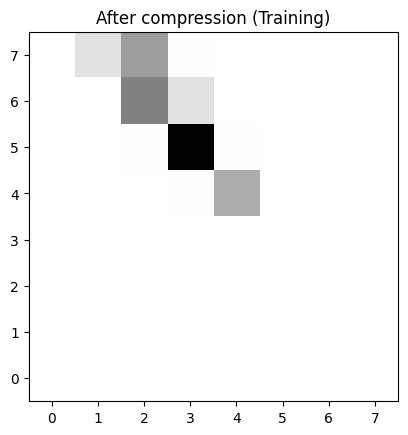

Epoch 137/200: 100%|██████████| 199/199 [00:00<00:00, 322.77it/s, Loss (BCE + VQ)=0.0221]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0296 MSE = 0.0013461433384384979 avg_perplexity = 29.900039088186904
Average validation set BCE loss: 0.03803022056818008


Epoch 138/200: 100%|██████████| 199/199 [00:00<00:00, 342.25it/s, Loss (BCE + VQ)=0.0314]


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0317,  Average loss: BCE = 0.0296 MSE = 0.0013290151462880847 avg_perplexity = 30.03237060086811
Average validation set BCE loss: 0.037876440584659575


Epoch 139/200: 100%|██████████| 199/199 [00:00<00:00, 338.31it/s, Loss (BCE + VQ)=0.0473]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0317,  Average loss: BCE = 0.0295 MSE = 0.001277558924103783 avg_perplexity = 30.6060640248821
Average validation set BCE loss: 0.037498146295547485


Epoch 150/200: 100%|██████████| 199/199 [00:00<00:00, 348.22it/s, Loss (BCE + VQ)=0.0319]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0318,  Average loss: BCE = 0.0296 MSE = 0.0012983324874342238 avg_perplexity = 30.688769882048796
Average validation set BCE loss: 0.03734586760401726


Epoch 151/200: 100%|██████████| 199/199 [00:00<00:00, 348.25it/s, Loss (BCE + VQ)=0.0331]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0314,  Average loss: BCE = 0.0292 MSE = 0.0011993239489828597 avg_perplexity = 30.871438529623212
Average validation set BCE loss: 0.037164997309446335
Before compression (Training)
Shape: (13, 8, 8)


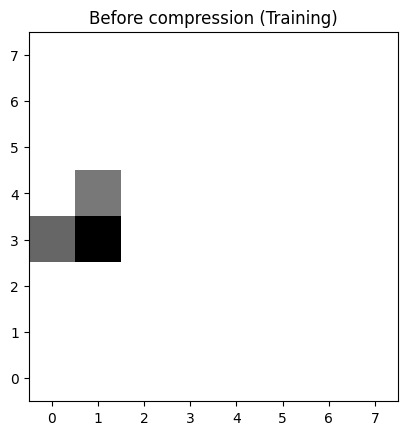

After compression (Training)
Shape: (1, 8, 8)


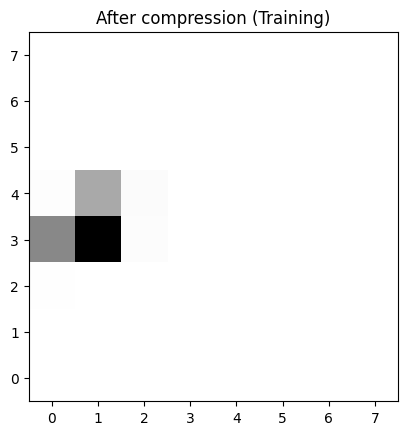

Epoch 152/200: 100%|██████████| 199/199 [00:00<00:00, 323.78it/s, Loss (BCE + VQ)=0.0261]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0315,  Average loss: BCE = 0.0293 MSE = 0.0012127606460857368 avg_perplexity = 31.21732567063528
Average validation set BCE loss: 0.03710343018174171


Epoch 153/200: 100%|██████████| 199/199 [00:00<00:00, 329.27it/s, Loss (BCE + VQ)=0.0303]


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0316,  Average loss: BCE = 0.0294 MSE = 0.0012443446341887977 avg_perplexity = 31.276529053347794
Average validation set BCE loss: 0.0374352365732193


Epoch 154/200: 100%|██████████| 199/199 [00:00<00:00, 321.75it/s, Loss (BCE + VQ)=0.037] 


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0290 MSE = 0.0010914127146427392 avg_perplexity = 32.99589816529547
Average validation set BCE loss: 0.03708557337522507


Epoch 165/200: 100%|██████████| 199/199 [00:00<00:00, 342.79it/s, Loss (BCE + VQ)=0.0365]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0290 MSE = 0.001098698476006525 avg_perplexity = 33.25472271981551
Average validation set BCE loss: 0.03709116280078888


Epoch 166/200: 100%|██████████| 199/199 [00:00<00:00, 323.11it/s, Loss (BCE + VQ)=0.0302]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0311,  Average loss: BCE = 0.0290 MSE = 0.001099692455179353 avg_perplexity = 33.35253207527813
Average validation set BCE loss: 0.03664543852210045
Before compression (Training)
Shape: (13, 8, 8)


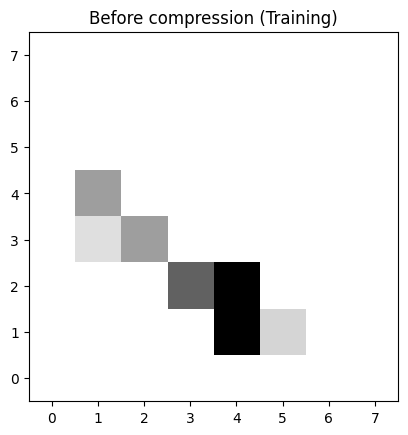

After compression (Training)
Shape: (1, 8, 8)


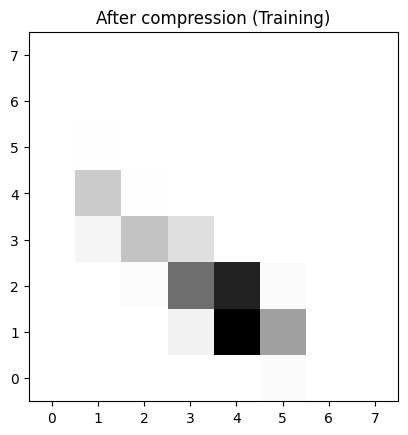

Epoch 167/200: 100%|██████████| 199/199 [00:00<00:00, 342.29it/s, Loss (BCE + VQ)=0.0311]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0312,  Average loss: BCE = 0.0290 MSE = 0.0011132883496498267 avg_perplexity = 33.46954956246381
Average validation set BCE loss: 0.03605715669691563


Epoch 168/200: 100%|██████████| 199/199 [00:00<00:00, 327.66it/s, Loss (BCE + VQ)=0.041] 


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0310,  Average loss: BCE = 0.0289 MSE = 0.0010462448828100184 avg_perplexity = 33.62952270699506
Average validation set BCE loss: 0.03633889593183994


Epoch 169/200: 100%|██████████| 199/199 [00:00<00:00, 313.83it/s, Loss (BCE + VQ)=0.0262]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0307,  Average loss: BCE = 0.0287 MSE = 0.000990830635623866 avg_perplexity = 36.73671611229978
Average validation set BCE loss: 0.03705966919660568


Epoch 180/200: 100%|██████████| 199/199 [00:00<00:00, 333.31it/s, Loss (BCE + VQ)=0.0299]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0286 MSE = 0.0009524489158586641 avg_perplexity = 37.12322050123358
Average validation set BCE loss: 0.03680311515927315


Epoch 181/200: 100%|██████████| 199/199 [00:00<00:00, 342.94it/s, Loss (BCE + VQ)=0.0263]


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0307,  Average loss: BCE = 0.0287 MSE = 0.0009907805925380233 avg_perplexity = 37.409292259408005
Average validation set BCE loss: 0.03598183989524841
Before compression (Training)
Shape: (13, 8, 8)


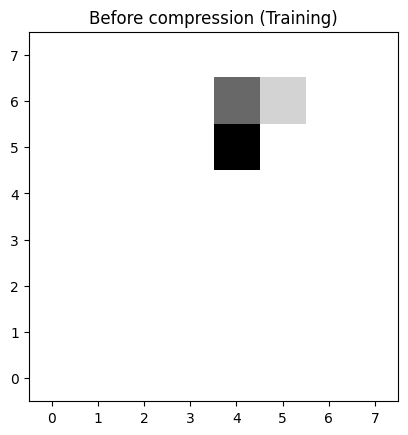

After compression (Training)
Shape: (1, 8, 8)


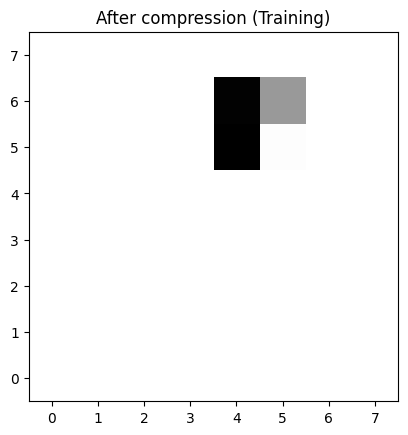

Epoch 182/200: 100%|██████████| 199/199 [00:00<00:00, 334.38it/s, Loss (BCE + VQ)=0.023] 


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0306,  Average loss: BCE = 0.0285 MSE = 0.0009494684423067275 avg_perplexity = 37.48710379289023
Average validation set BCE loss: 0.03626808300614357


Epoch 183/200: 100%|██████████| 199/199 [00:00<00:00, 339.25it/s, Loss (BCE + VQ)=0.0244]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0307,  Average loss: BCE = 0.0287 MSE = 0.0009714879684065979 avg_perplexity = 37.83900868593149
Average validation set BCE loss: 0.03657724261283875


Epoch 184/200: 100%|██████████| 199/199 [00:00<00:00, 337.28it/s, Loss (BCE + VQ)=0.0376]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0302,  Average loss: BCE = 0.0282 MSE = 0.0008266284399614412 avg_perplexity = 40.55542004647567
Average validation set BCE loss: 0.03552725240588188


Epoch 195/200: 100%|██████████| 199/199 [00:00<00:00, 340.69it/s, Loss (BCE + VQ)=0.0263]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0302,  Average loss: BCE = 0.0283 MSE = 0.0008419009127967696 avg_perplexity = 41.16933753622237
Average validation set BCE loss: 0.03622362464666366


Epoch 196/200: 100%|██████████| 199/199 [00:00<00:00, 339.64it/s, Loss (BCE + VQ)=0.0356]


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0300,  Average loss: BCE = 0.0281 MSE = 0.0008071190923283896 avg_perplexity = 41.177661176901964
Average validation set BCE loss: 0.03537040986120701
Before compression (Training)
Shape: (13, 8, 8)


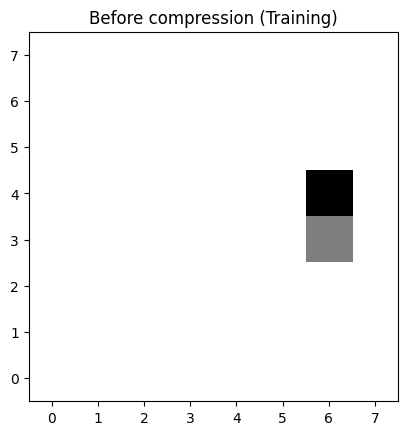

After compression (Training)
Shape: (1, 8, 8)


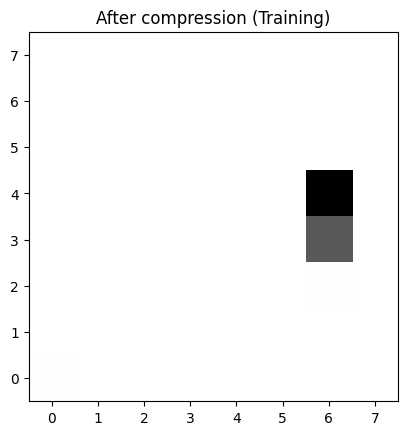

Epoch 197/200: 100%|██████████| 199/199 [00:00<00:00, 335.84it/s, Loss (BCE + VQ)=0.0296]


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0298,  Average loss: BCE = 0.0280 MSE = 0.0007755032859873682 avg_perplexity = 41.80049909658767
Average validation set BCE loss: 0.03596742898225784


Epoch 198/200: 100%|██████████| 199/199 [00:00<00:00, 341.27it/s, Loss (BCE + VQ)=0.021] 


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0279 MSE = 0.0007616696342821209 avg_perplexity = 42.052808780766014
Average validation set BCE loss: 0.03534117005765438


Epoch 199/200: 100%|██████████| 199/199 [00:00<00:00, 336.72it/s, Loss (BCE + VQ)=0.0292]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0297,  Average loss: BCE = 0.0280 MSE = 0.0007611017180758823 avg_perplexity = 42.19089930740433
Average validation set BCE loss: 0.03679332435131073


Epoch 200/200: 100%|██████████| 199/199 [00:00<00:00, 339.51it/s, Loss (BCE + VQ)=0.0277]


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0296,  Average loss: BCE = 0.0279 MSE = 0.0007329452303168013 avg_perplexity = 42.4871373296383
Average validation set BCE loss: 0.03519895300269127
Before compression (Validation)
Shape: (64, 8, 8)


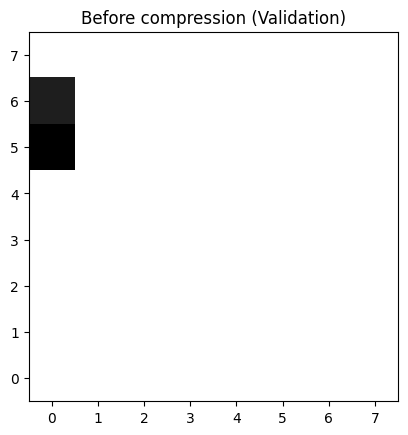

After compression (Validation)
Shape: (1, 8, 8)


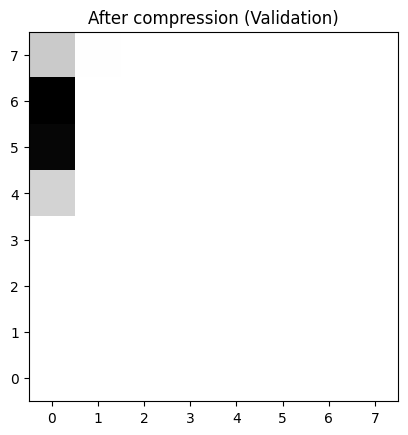

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


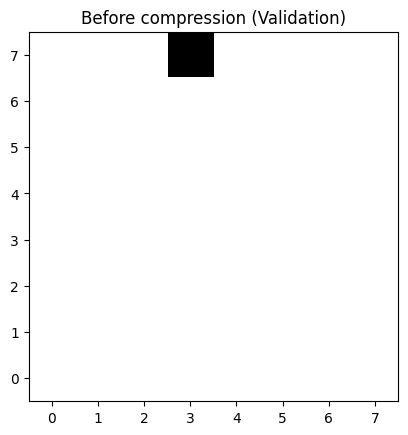

After compression (Validation)
Shape: (1, 8, 8)


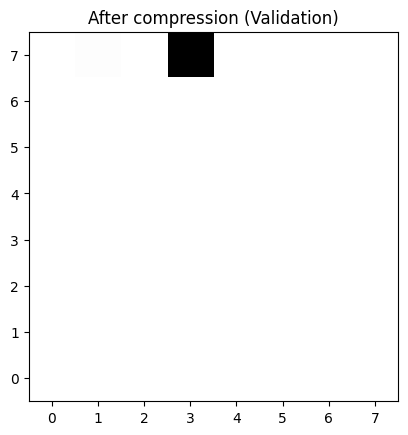

----------------------------------------
Patch = 1 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


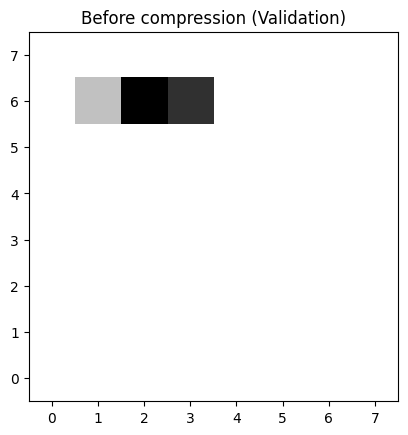

After compression (Validation)
Shape: (1, 8, 8)


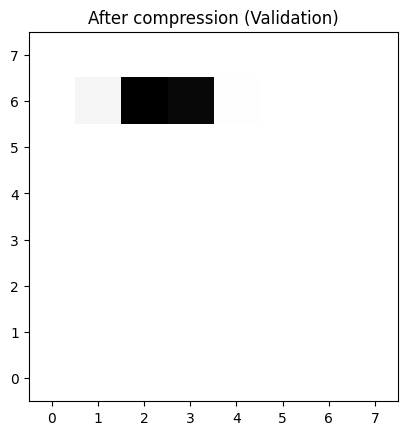

----------------------------------------
Patch = 2 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


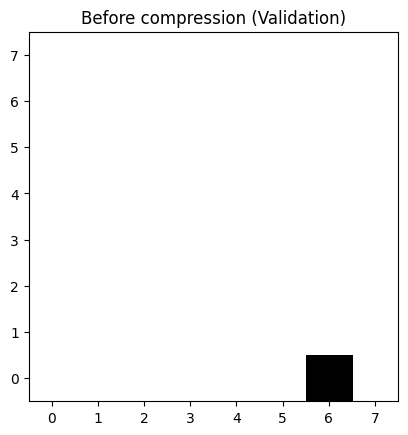

After compression (Validation)
Shape: (1, 8, 8)


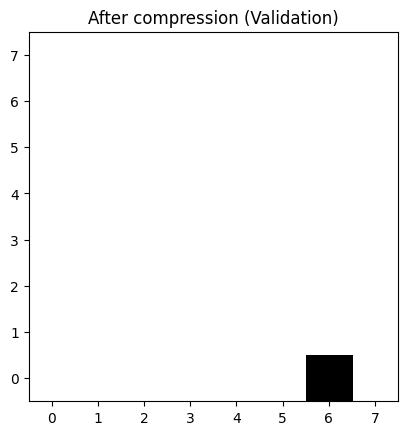

----------------------------------------
Patch = 3 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


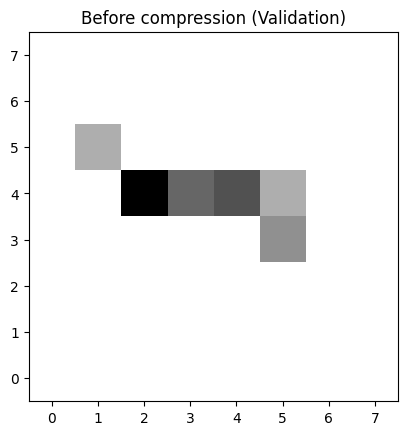

After compression (Validation)
Shape: (1, 8, 8)


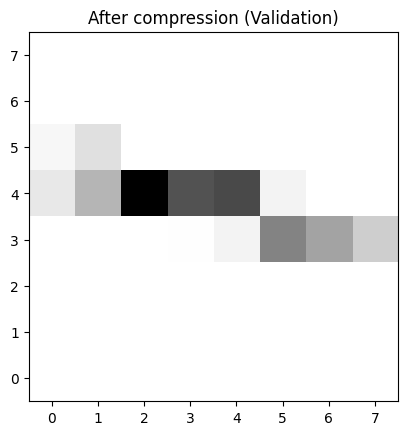

----------------------------------------
Patch = 4 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (3904) x (2)
Compression ratio = 0.0012155710490035707
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 62475.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [21]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [22]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


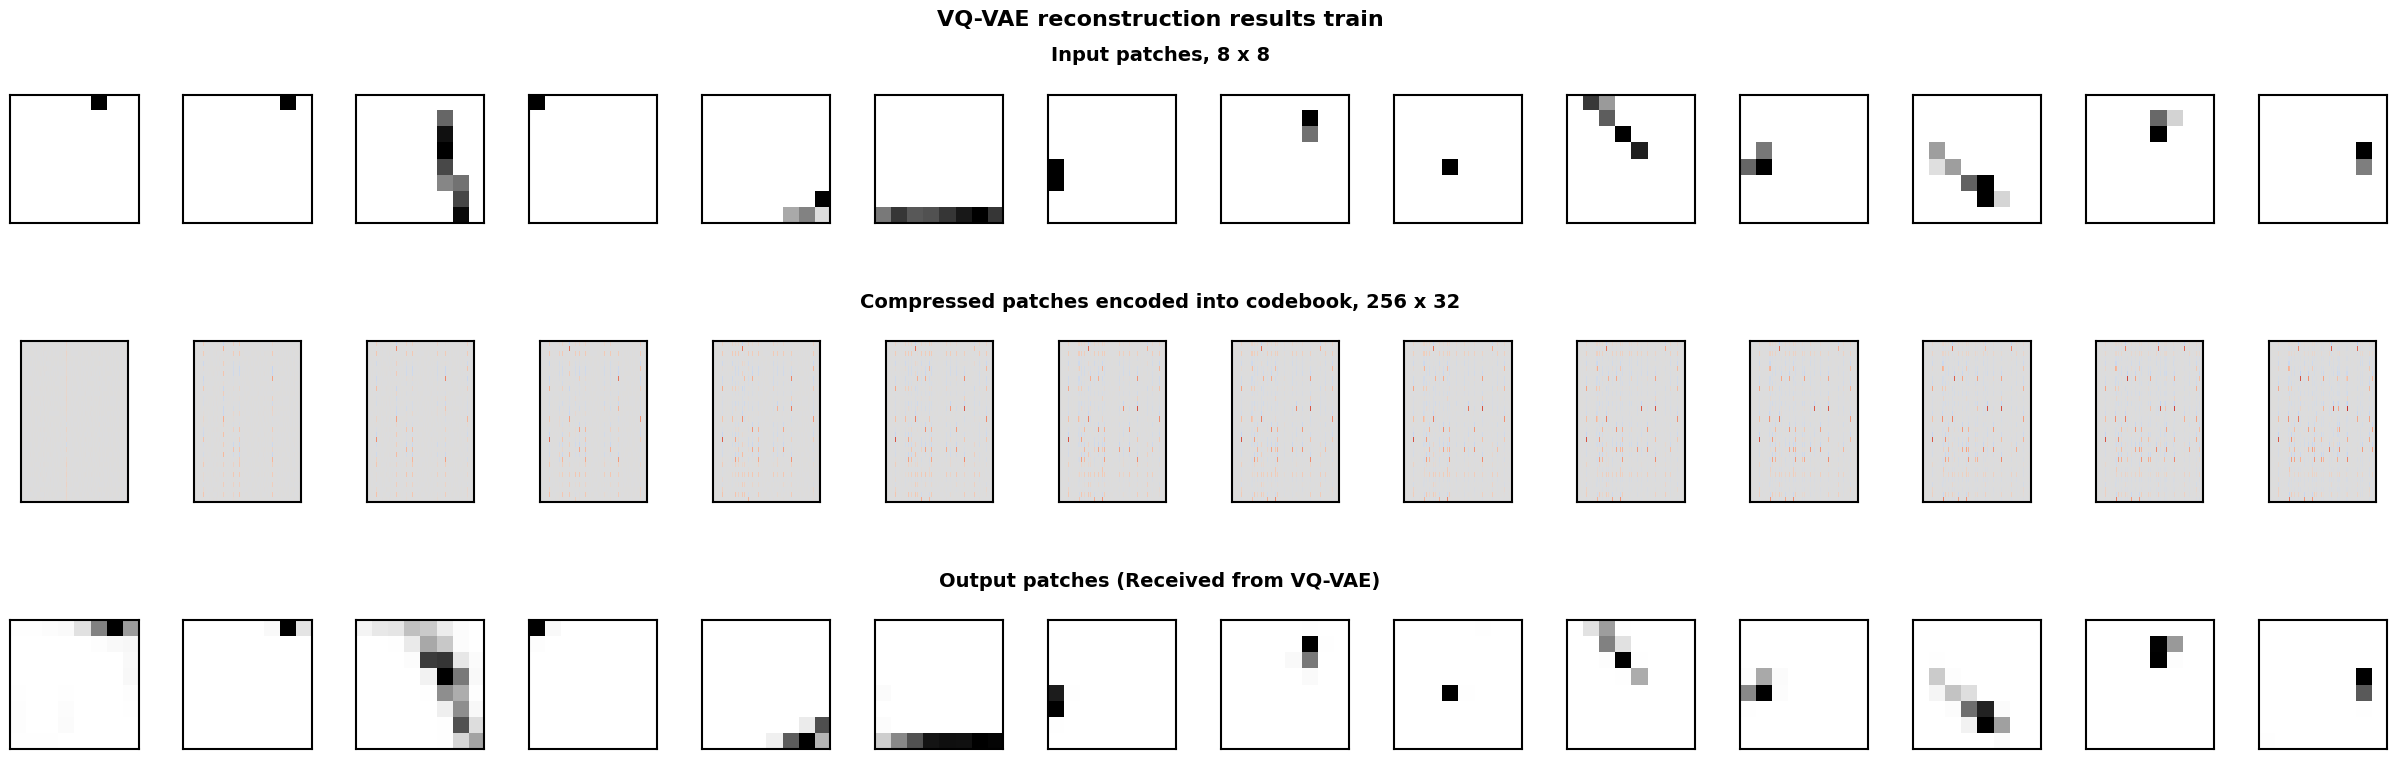

In [23]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

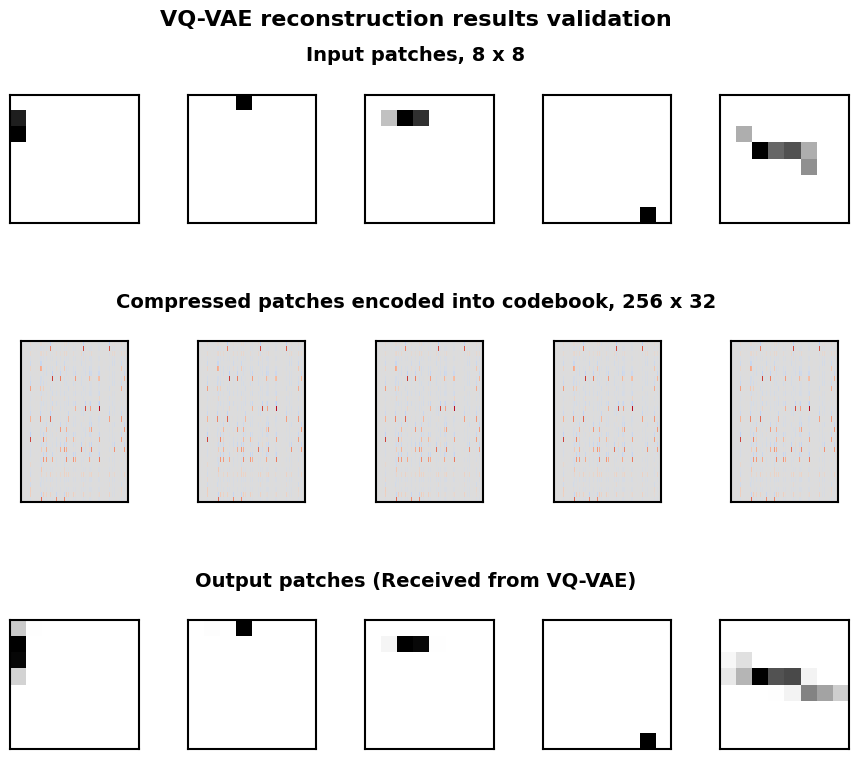

In [24]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [25]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.12063710391521454
encoder.1.weight 0.003987743053585291
encoder.1.bias 0.006558854598551989
encoder.3.weight 0.05837108939886093
encoder.4.weight 0.003464302746579051
encoder.4.bias 0.003569473046809435
encoder.6.weight 0.05619669705629349
encoder.7.weight 0.007944663055241108
encoder.7.bias 0.005327835213392973
encoder.8.stack.0.res_block.1.weight 0.021247433498501778
encoder.8.stack.0.res_block.3.weight 0.014372358098626137
encoder.8.stack.1.res_block.1.weight 0.0209172572940588
encoder.8.stack.1.res_block.3.weight 0.02570934407413006
fc_encoder_input.layers.0.weight 0.013069943524897099
fc_encoder_input.layers.0.bias 7.508562660518692e-09
fc_encoder_input.layers.1.weight 0.0036509232595562935
fc_encoder_input.layers.1.bias 0.0031634385231882334
vq_layer.embedding.weight 0.0008544387528672814
fc_decoder_input.layers.0.weight 0.0008273599669337273
fc_decoder_input.layers.0.bias 8.586369837360053e-09
fc_decoder_input.layers.1.weight 0.00111888

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


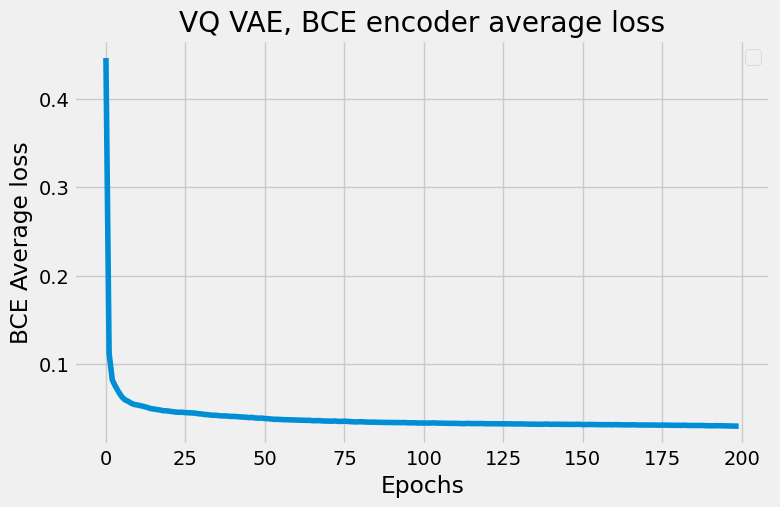

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [26]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [27]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.23830
Based on test set (size = 45), average codebook perplexity = 43.72812/256
Saved VQ-VAE test results


In [28]:
len(patches_before_test)

6

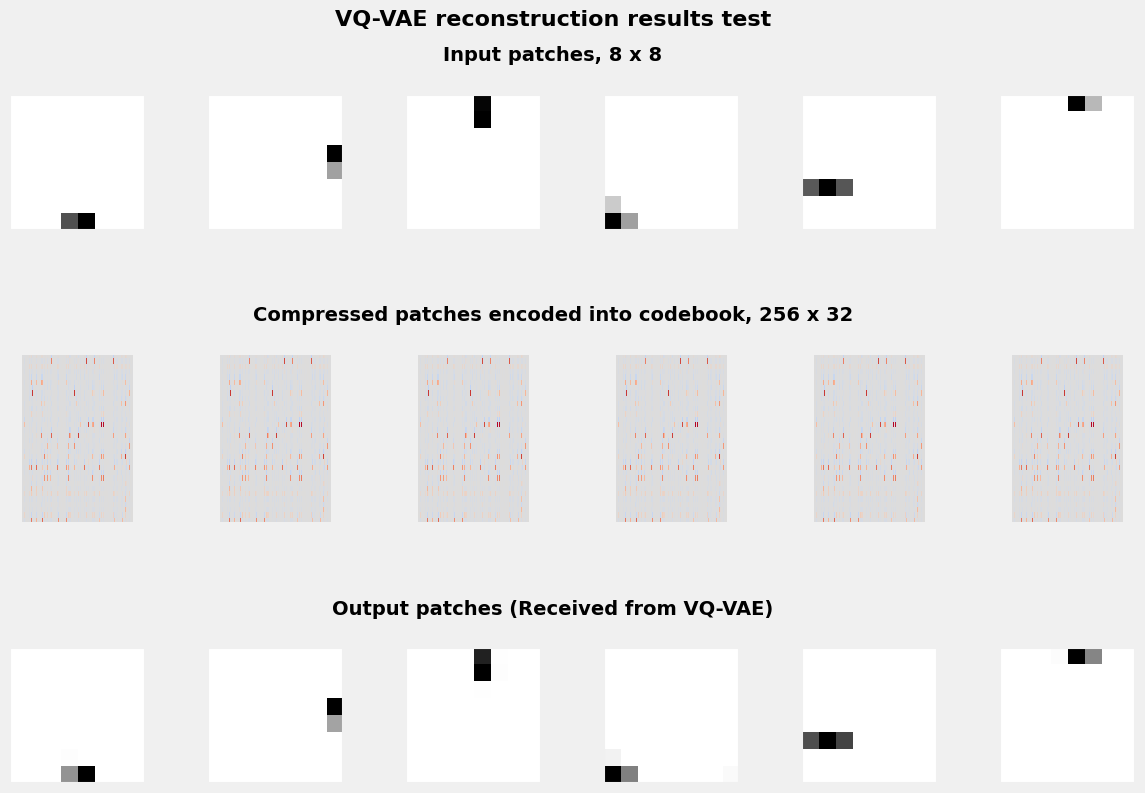

In [29]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

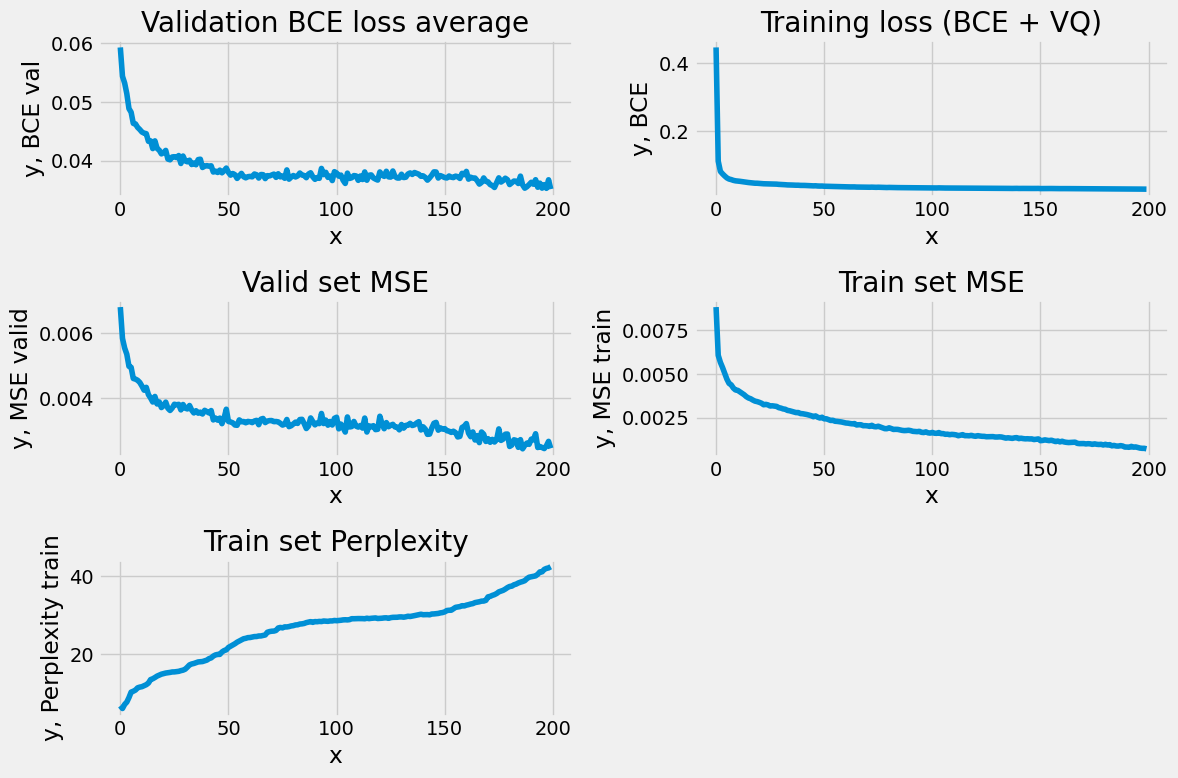

In [30]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
